# Project 3 — Clustering & Classification
### Data Mining Fundamentals — Complete Implementation

**Dataset:** Bank Marketing dataset (`bank_cleaned.xlsx`)

This notebook is designed to run on Google Colab and uses the modular `src` package from the GitHub repository.

In [1]:
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/AHK8213/DataMining_Clustering_Classification.git"

PROJECT_ROOT = "/content/DataMining_Clustering_Classification"  # only for Colab

# Move out before deleting
os.chdir("/content")

if os.path.exists(PROJECT_ROOT):
    print("Removing old repository...")
    shutil.rmtree(PROJECT_ROOT)

print("Cloning repository...")
subprocess.run(
    ["git", "clone", REPO_URL],
    check=True
)

os.chdir(PROJECT_ROOT)

sys.path.append(os.path.abspath("."))
sys.path.append(os.path.abspath("./src"))

print("Current directory:", os.getcwd())
print("Setup complete!")

Removing old repository...
Cloning repository...
Current directory: /content/DataMining_Clustering_Classification
Setup complete!


In [2]:
# ============================================================================
# SETUP: Install Dependencies
# ============================================================================

print("\n" + "=" * 70)
print("INSTALLING DEPENDENCIES")
print("=" * 70)

# Install requirements
!pip install -q numpy pandas scipy scikit-learn
!pip install -q matplotlib seaborn plotly
!pip install -q torch
!pip install -q xgboost
!pip install -q hdbscan scikit-fuzzy
!pip install -q joblib tqdm

print("\nAll dependencies installed successfully!")

# Verify installations
import numpy as np
import pandas as pd
import sklearn
import torch
import xgboost

print(f"\nNumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"XGBoost version: {xgboost.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


INSTALLING DEPENDENCIES

All dependencies installed successfully!

NumPy version: 2.0.2
Pandas version: 2.2.2
Scikit-learn version: 1.6.1
PyTorch version: 2.11.0+cu128
XGBoost version: 3.3.0
CUDA available: True


---

# PART A — Setup & Data Preparation

## A.1 Imports & Configuration

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os # Added import for os module

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# Ensure src is in path
sys.path.append(os.path.abspath("."))
sys.path.append(os.path.abspath("./src"))

# Import all modules from src package
try:
    from src import (
        # Configuration
        RANDOM_STATE,
        NUM_COLS,
        CAT_COLS,
        TARGET_COL,
        K_RANGE,
        DATA_URL,
        DEVICE,
        GPU_AVAILABLE,
        XGB_DEVICE,

        # Utils
        reduce_memory,
        get_sample,
        hopkins_statistic,
        dunn_index,
        compute_clustering_metrics,
        timer,
        cleanup,

        # Data Preparation
        load_data,
        clean_data,
        create_preprocessor,
        fit_pca,
        prepare_data_for_clustering,
        prepare_data_for_classification,

        # Clustering
        ClusteringRunner,
        run_all_clustering,
        OptimalKDeterminer,
        ClusteringComparator,
        determine_optimal_k,
        ClusteringTendency,
        OptimalKAnalyzer,
        ClusterProfiler,

        # Classification
        prepare_classification_data,
        prepare_pre_call_data,
        BaseClassifier,
        create_all_base_classifiers,
        train_and_evaluate_classifier,
        create_neural_network,
        manual_bagging,
        manual_adaboost,
        run_boosting_depth_experiment,
        compute_classification_metrics,
        cross_validate_classifier,
        cross_validate_multiple_classifiers,
        lift_at_k,
        OverfittingAnalyzer,
        PreCallAnalyzer,
        compare_small_vs_full_dataset,

        # Visualization
        create_figure,
        save_figure,
        save_all_figures,
        plot_cluster_pca,
        plot_model_comparison,
        plot_training_history,
        plot_feature_importance,

        # Sampling (unified sampling manager - replaces scattered
        # get_sample / auto_subsample / local tiered-dataset helpers)
        create_tiered_datasets,

        # Caching (avoids re-running expensive steps on every re-run)
        cache_result,

        # Final Summary
        create_clustering_final_table,
        create_classification_final_table,
        compute_extrinsic_evaluation,
        interpret_extrinsic_evaluation,
        generate_final_discussion,
        ProjectSummary,
        create_complete_summary,
    )
    from src.config import FIGURES_DIR
    print("All modules imported successfully!")

    # These print statements are moved inside the try block as they depend on imported variables
    print("=" * 70)
    print("PROJECT 3: CLUSTERING & CLASSIFICATION")
    print("=" * 70)
    print(f"RANDOM_STATE: {RANDOM_STATE}")
    print(f"GPU available: {GPU_AVAILABLE} | Device: {DEVICE}")
    print(f"XGBoost device: {XGB_DEVICE}")
    print("=" * 70)

except ImportError as e:
    print(f"Import error: {e}")
    !find src -maxdepth 2 -type f
    print("Please ensure the repository structure is correct:")
    print("  DataMining_Clustering_Classification/")
    print("  ├── src/")
    print("  │   ├── __init__.py")
    print("  │   └── ...")
    print("  └── notebooks/")
    print("      └── this_notebook.ipynb")
    # Print project title even if config is unavailable due to import error
    print("=" * 70)
    print("PROJECT 3: CLUSTERING & CLASSIFICATION (Configuration variables unavailable due to import error)")
    print("=" * 70)


All modules imported successfully!
PROJECT 3: CLUSTERING & CLASSIFICATION
RANDOM_STATE: 42
GPU available: True | Device: cuda
XGBoost device: cuda


## A.2 Memory Optimization

In [4]:
# ============================================================================
# A.2 Memory Optimization
# ============================================================================

print("\n" + "=" * 70)
print("A.2 MEMORY OPTIMIZATION")
print("=" * 70)

def analyze_memory_usage(df):
    """Analyze and report memory usage of dataframe."""
    memory_before = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage before optimization: {memory_before:.2f} MB")

    df_optimized = reduce_memory(df)
    memory_after = df_optimized.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage after optimization: {memory_after:.2f} MB")
    print(f"Reduction: {(1 - memory_after/memory_before) * 100:.1f}%")

    return df_optimized

print("Memory optimization ready.")
print("Note: Using float64 throughout for numerical consistency.")


A.2 MEMORY OPTIMIZATION
Memory optimization ready.
Note: Using float64 throughout for numerical consistency.


## A.3 Data Loading & Cleaning

In [5]:
# ============================================================================
# A.3 Data Loading & Cleaning
# ============================================================================

print("\n" + "=" * 70)
print("A.3 DATA LOADING & CLEANING")
print("=" * 70)

# Load data
df = load_data(local_path=True, verbose=True)
print(f"Raw shape: {df.shape}")

# Apply memory optimization
df = analyze_memory_usage(df)

# Clean data
df = clean_data(df, verbose=True)
print(f"After cleaning: {df.shape}")

# Generate data quality report
print("\nData Quality Report:")
print("-" * 40)
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


A.3 DATA LOADING & CLEANING
Loading dataset from local file: /content/DataMining_Clustering_Classification/data/bank_cleaned.xlsx
Loaded data shape: (45211, 17)
Raw shape: (45211, 17)
Memory usage before optimization: 25.79 MB
Memory usage: 25.79 MB -> 1.25 MB (95.1% reduction)
Memory usage after optimization: 1.25 MB
Reduction: 95.1%
Dropping constant columns: ['pdays', 'previous']
Cleaned shape: (45211, 15)
Rows removed: 0
Missing values after cleaning: 0
After cleaning: (45211, 15)

Data Quality Report:
----------------------------------------
Total rows: 45,211
Total columns: 15
Missing values: 0
Duplicate rows: 0
Memory usage: 1.47 MB


## A.4 Feature Selection

In [6]:
# ============================================================================
# A.4 Feature Selection
# ============================================================================

print("\n" + "=" * 70)
print("A.4 FEATURE SELECTION")
print("=" * 70)

print(f"Available columns: {df.columns.tolist()}")
print(f"\nNumerical columns ({len(NUM_COLS)}): {NUM_COLS}")
print(f"Categorical columns ({len(CAT_COLS)}): {CAT_COLS}")
print(f"Target column: {TARGET_COL}")

print("\nFeature Selection Summary:")
print("-" * 40)
print(f"Features retained: {len(NUM_COLS) + len(CAT_COLS)}")
print(f"Features excluded: {df.shape[1] - len(NUM_COLS) - len(CAT_COLS) - 1}")

X_cluster_df = df.drop(columns=[TARGET_COL])
print(f"\nFeature matrix shape: {X_cluster_df.shape}")


A.4 FEATURE SELECTION
Available columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'poutcome', 'y']

Numerical columns (5): ['age', 'balance', 'day', 'duration', 'campaign']
Categorical columns (7): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month']
Target column: y

Feature Selection Summary:
----------------------------------------
Features retained: 12
Features excluded: 2

Feature matrix shape: (45211, 14)


## A.5 PCA

In [7]:
# ============================================================================
# A.5 PCA
# ============================================================================

print("\n" + "=" * 70)
print("A.5 PCA")
print("=" * 70)

# Create preprocessor
preprocessor = create_preprocessor(NUM_COLS, CAT_COLS)

# Fit preprocessor and transform
X_full = preprocessor.fit_transform(X_cluster_df).astype(np.float64)
print(f"Feature matrix shape: {X_full.shape}")
print(f"Feature matrix dtype: {X_full.dtype}")
print(f"Memory usage: {X_full.nbytes / 1024**2:.2f} MB")

# Fit PCA once on full dataset (cached - PCA is deterministic given
# X_full, so re-running the notebook reuses this instead of refitting)
pca, X_pca_full = cache_result(
    "pca_fit_transform",
    lambda: (lambda p: (p, p.transform(X_full)))(fit_pca(X_full, verbose=True))
)

print(f"\nPCA shape: {X_pca_full.shape}")
print(f"Explained variance (first 10 components): {pca.explained_variance_ratio_[:10].sum():.2%}")


A.5 PCA
Feature matrix shape: (45211, 47)
Feature matrix dtype: float64
Memory usage: 16.21 MB
Fitting PCA with 2 components on 45,211 rows...
Explained variance: PC1=13.56%, PC2=13.39%
Total explained variance: 26.95%
  💾 Cached 'pca_fit_transform' -> pca_fit_transform.pkl

PCA shape: (45211, 2)
Explained variance (first 10 components): 26.95%


## A.6 Tiered Dataset Preparation

In [8]:
# ============================================================================
# A.6 Tiered Dataset Preparation
# ============================================================================

print("\n" + "=" * 70)
print("A.6 TIERED DATASET PREPARATION")
print("=" * 70)

# Uses the unified sampling manager (src/sampling.py) instead of a
# notebook-local helper, so this logic is defined in exactly one place.
tiered_sizes = {
    'small': 0.05,
    'medium': 0.20,
    'large': 0.50,
    'full': 1.00
}

tiered_datasets = create_tiered_datasets(X_full, tiered_sizes, random_state=RANDOM_STATE)
print("\nTiered datasets created for scalability experiments.")



A.6 TIERED DATASET PREPARATION
small: 2,260 samples (5%)
medium: 9,042 samples (20%)
large: 22,605 samples (50%)
full: 45,211 samples (100%)

Tiered datasets created for scalability experiments.


---

# PART B — Clustering Experiments

## B.1 Clustering Tendency


B.1 CLUSTERING TENDENCY
Computing Hopkins statistic with 3000 samples...
Hopkins statistic: 0.760
Interpretation: High clustering tendency (strongly clusterable)
Computing spatial histogram KL tendency (47D -> 3D, 5 bins/dim)...
PCA-reduced to 3D (explained variance: 38.1%)
KL(data || random): 1.4333
Symmetric KL: 3.7919
JS divergence: 0.3303
Strong clustering tendency (JS=0.330). Data's spatial distribution differs substantially from random.

CLUSTERING TENDENCY REPORT

Dataset:
  Samples: 45,211
  Features: 47

Hopkins Statistic: 0.7602
Interpretation: High clustering tendency (strongly clusterable)
Clusterability: YES

----------------------------------------------------------------------
Spatial Histogram KL Analysis (Data vs. Random, no clustering required):
  Dimensions used: 3 of 47 (PCA-reduced)
  Bins per dimension: 5
  KL(data || random): 1.4333
  Symmetric KL: 3.7919
  Jensen-Shannon Divergence: 0.3303
  Interpretation: Strong clustering tendency (JS=0.330). Data's spatial 

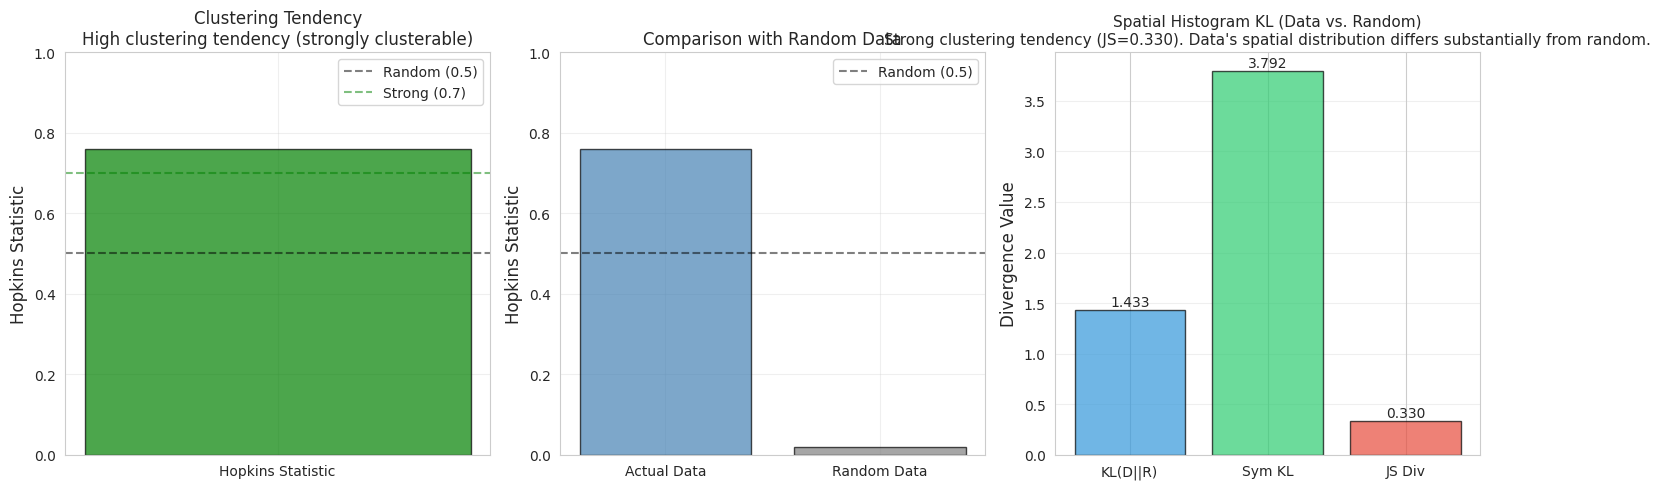

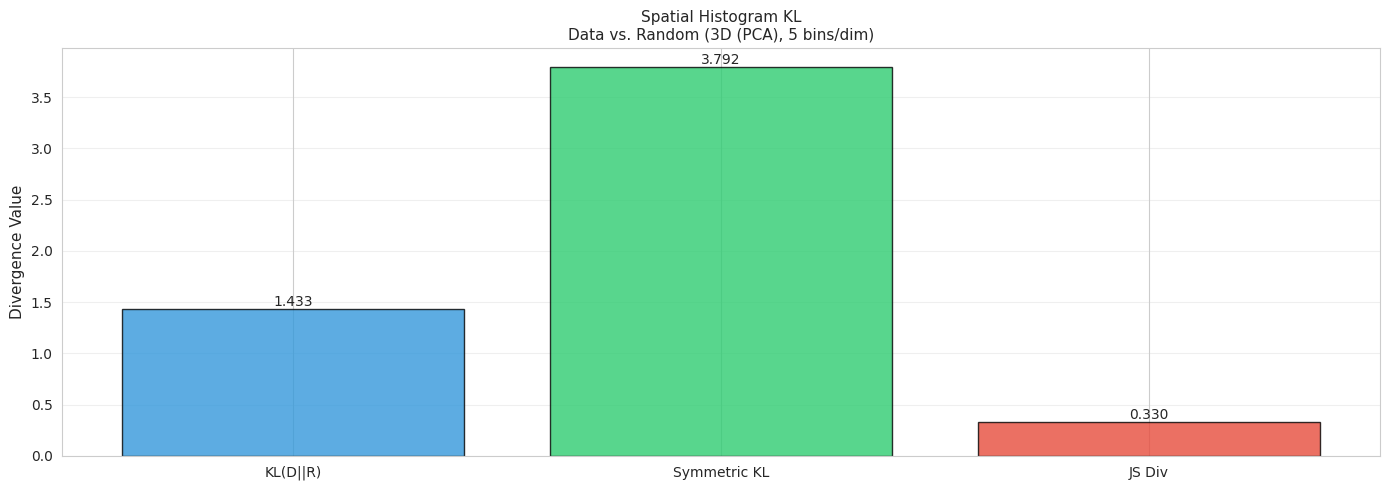


SUMMARY
Hopkins Statistic: 0.7602 → High clustering tendency (strongly clusterable)
Jensen-Shannon Divergence (data vs. random): 0.3303 → Strong clustering tendency (JS=0.330). Data's spatial distribution differs substantially from random.

Overall Assessment: ✓ CLUSTERABLE


In [9]:
# ============================================================================
# B.1 Clustering Tendency (Hopkins Statistic + Spatial Histogram KL)
# ============================================================================

print("\n" + "=" * 70)
print("B.1 CLUSTERING TENDENCY")
print("=" * 70)

# Initialize and compute clustering tendency
tendency = ClusteringTendency(X_full, verbose=True)
H = tendency.compute_hopkins()

# Spatial histogram KL divergence: compares the EPMF of the actual data
# against the EPMF of uniformly random data over the same bounding box.
# No preliminary clustering required (PCA-reduces to max_dims first,
# since a full joint histogram is only meaningful in low dimensions).
hist_results = tendency.compute_histogram_tendency(n_bins=5, max_dims=3, verbose=True)

# Generate comprehensive report
print(tendency.get_report())

# Create comprehensive visualization
fig = tendency.plot(show_random=True, show_histogram_kl=True, figsize=(15, 5))
plt.show()

fig_hist = tendency.plot_histogram_tendency()
plt.show()

# Save all figures
save_all_figures(
    {
        'hopkins_summary': fig,
        'spatial_histogram_kl': fig_hist
    },
    subdir='clustering_tendency'
)

# Print concise summary
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Hopkins Statistic: {H:.4f} → {tendency.interpret()}")
print(f"Jensen-Shannon Divergence (data vs. random): {hist_results['js_divergence']:.4f} → {tendency.interpret_histogram_tendency()}")
print(f"\nOverall Assessment: {'✓ CLUSTERABLE' if tendency.is_clusterable() else '✗ NOT CLUSTERABLE'}")
print("=" * 70)


## B.2 Optimal K Determination


B.2 OPTIMAL K DETERMINATION
Computing metrics for K=2..10...
  K=2: SSE=369706, Sil=0.096, CH=4388, DB=3.067
  K=3: SSE=340572, Sil=0.112, CH=4311, DB=2.493
  K=4: SSE=316193, Sil=0.091, CH=4263, DB=2.552
  K=5: SSE=306230, Sil=0.076, CH=3706, DB=2.460
  K=6: SSE=282661, Sil=0.090, CH=3935, DB=2.189
  K=7: SSE=282031, Sil=0.076, CH=3351, DB=2.324
  K=8: SSE=273502, Sil=0.071, CH=3127, DB=2.531
  K=9: SSE=268309, Sil=0.068, CH=2899, DB=2.594
  K=10: SSE=263495, Sil=0.075, CH=2714, DB=2.516

Optimal K by different criteria:
  Silhouette: 3
  Calinski-Harabasz: 2
  Davies-Bouldin: 6

Optimal K by different criteria:
  Silhouette: 3
  Calinski-Harabasz: 2
  Davies-Bouldin: 6


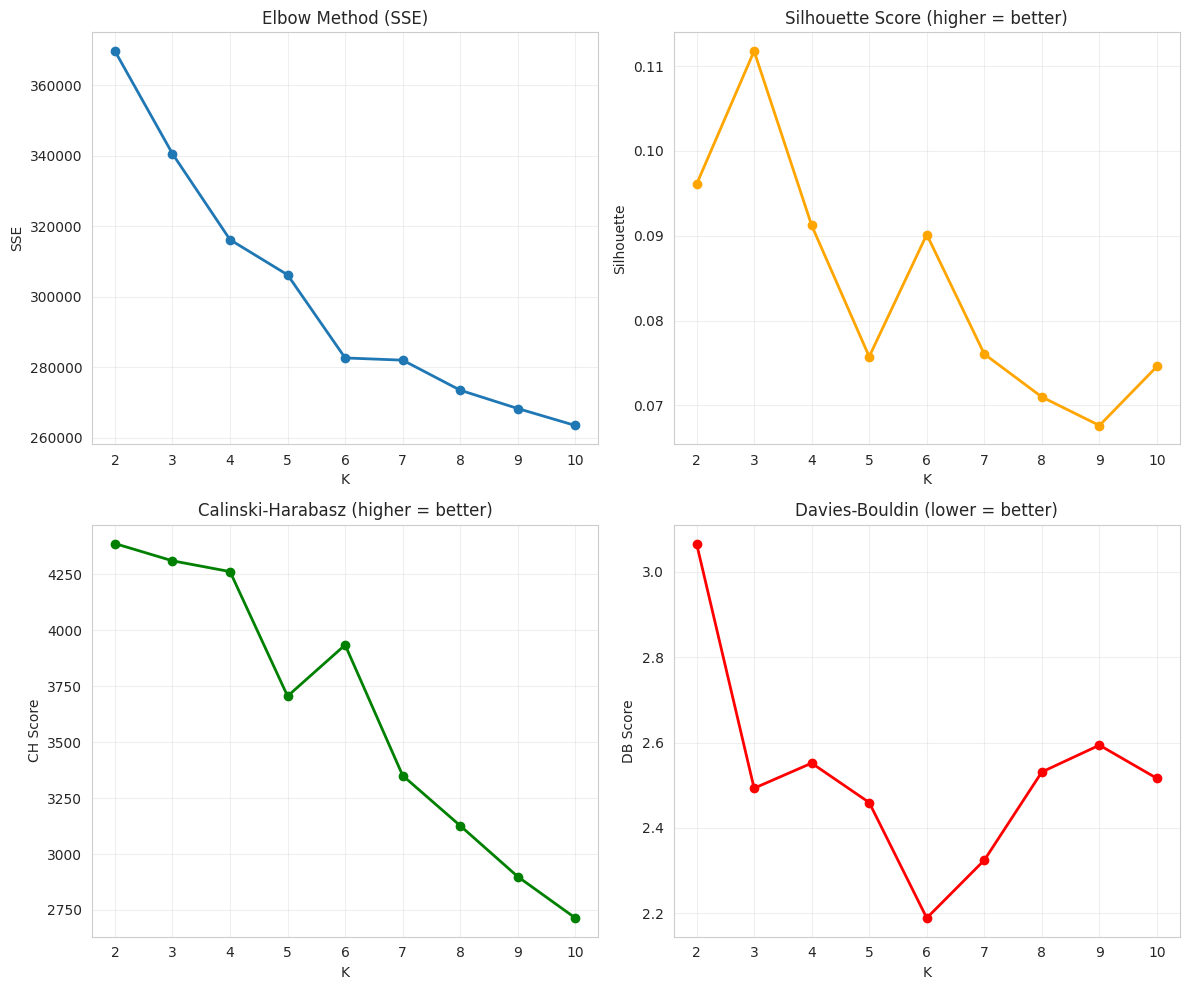


Optimal K (majority vote): 3
Best by criteria: {'silhouette': 3, 'calinski_harabasz': 2, 'davies_bouldin': 6}


In [10]:
# ============================================================================
# B.2 Optimal K Determination
# - Elbow Method (visualization only)
# - Silhouette Score (primary selection)
# ============================================================================

print("\n" + "=" * 70)
print("B.2 OPTIMAL K DETERMINATION")
print("=" * 70)

best_k, best_by_criteria, determiner = determine_optimal_k(
    X_full, k_range=K_RANGE, verbose=True
)

fig = determiner.plot()
plt.show()
save_all_figures({'elbow_silhouette': fig}, subdir='optimal_k')

print(f"\nOptimal K (majority vote): {best_k}")
print(f"Best by criteria: {best_by_criteria}")

## B.3 Clustering Algorithms


B.3 CLUSTERING ALGORITHMS
Running all clustering algorithms...

Running all clustering algorithms on 45,211 points
Auto-subsampling: ON

K-Means                        | clusters=  3 | noise=  0.0% | 2.47s
Bisecting K-Means              | clusters=  3 | noise=  0.0% | 0.10s
  ⚡ K-Medoids: subsampled from 45,211 to 20,000 points
K-Medoids                      | clusters=  3 | noise= 55.8% | 17.24s [subsampled 20,000/45,211]
K-Median                       | clusters=  3 | noise=  0.0% | 0.25s
Fuzzy C-Means                  | clusters=  3 | noise=  0.0% | 0.21s
  ⚡ Kernel K-Means: subsampled from 45,211 to 20,000 points
Kernel K-Means                 | clusters=  3 | noise= 55.8% | 40.36s [subsampled 20,000/45,211]
DBSCAN                         | clusters= 48 | noise= 35.2% | 9.13s
OPTICS                         | clusters=196 | noise= 91.1% | 348.17s
HDBSCAN                        | clusters= 25 | noise= 90.3% | 149.09s
  ⚡ Agglomerative (Ward): subsampled from 45,211 to 20,000 points


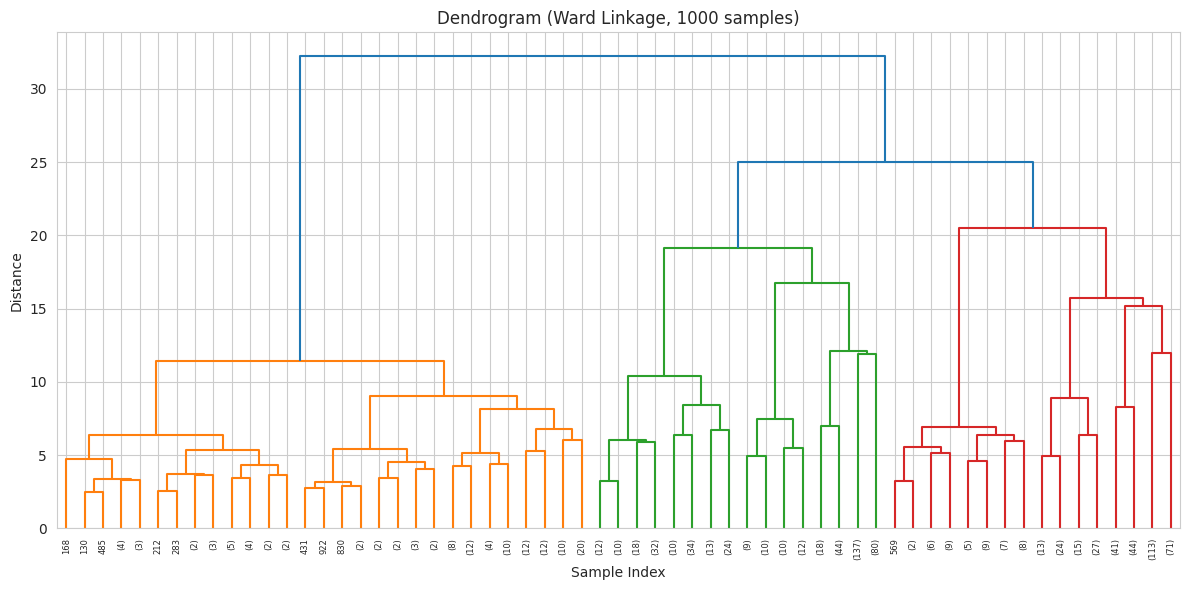

['/content/DataMining_Clustering_Classification/figures/clustering_results/dendrogram.png']

In [11]:
# ============================================================================
# B.3 Clustering Algorithms
# - Centroid-Based: K-Means, Bisecting K-Means, K-Medoids, K-Median, Kernel K-Means, Fuzzy C-Means
# - Density-Based: DBSCAN, OPTICS, HDBSCAN
# - Hierarchical: Agglomerative (Ward, Single, Complete) + Dendrogram
# - Probabilistic: Gaussian Mixture Model
# ============================================================================

print("\n" + "=" * 70)
print("B.3 CLUSTERING ALGORITHMS")
print("=" * 70)

print("Running all clustering algorithms...")
# Cached: this step runs every clustering algorithm and is by far the
# most expensive cell in the notebook. On re-runs with the same data
# and best_k, the cached labels/runtimes are reused instead of
# recomputing everything from scratch.
labels_dict, runtimes = cache_result(
    f"clustering_labels_k{best_k}",
    lambda: run_all_clustering(X_full, k=best_k, verbose=True)
)

print(f"\nRan {len(labels_dict)} algorithms")
print(f"Algorithms: {list(labels_dict.keys())}")

# Generate dendrogram for hierarchical clustering
print("\nGenerating dendrogram...")
from scipy.cluster.hierarchy import dendrogram, linkage

fig, ax = plt.subplots(figsize=(12, 6))
linkage_matrix = linkage(X_full[:1000], method='ward')
dendrogram(linkage_matrix, truncate_mode='level', p=5, ax=ax)
ax.set_title("Dendrogram (Ward Linkage, 1000 samples)")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()
save_all_figures({'dendrogram': fig}, subdir='clustering_results')

## B.4 Comprehensive Algorithm Comparison


B.4 COMPREHENSIVE ALGORITHM COMPARISON
Computing metrics for: K-Means
Computing metrics for: Bisecting K-Means
Computing metrics for: K-Medoids
Computing metrics for: K-Median
Computing metrics for: Fuzzy C-Means
Computing metrics for: Kernel K-Means
Computing metrics for: DBSCAN
Computing metrics for: OPTICS
Computing metrics for: HDBSCAN
Computing metrics for: Agglomerative (Ward)
Computing metrics for: Agglomerative (Single)
Computing metrics for: Agglomerative (Complete)
Computing metrics for: GMM

Comparison results:
                        n_clusters  noise_pct  silhouette  davies_bouldin  \
OPTICS                       196.0  91.072969    0.283283        1.201036   
Agglomerative (Single)         3.0  55.762978    0.162041        0.664947   
HDBSCAN                       25.0  90.285550    0.161014        1.736977   
K-Means                        3.0   0.000000    0.117931        2.430272   
Kernel K-Means                 3.0  55.762978    0.110164        2.509029   

        

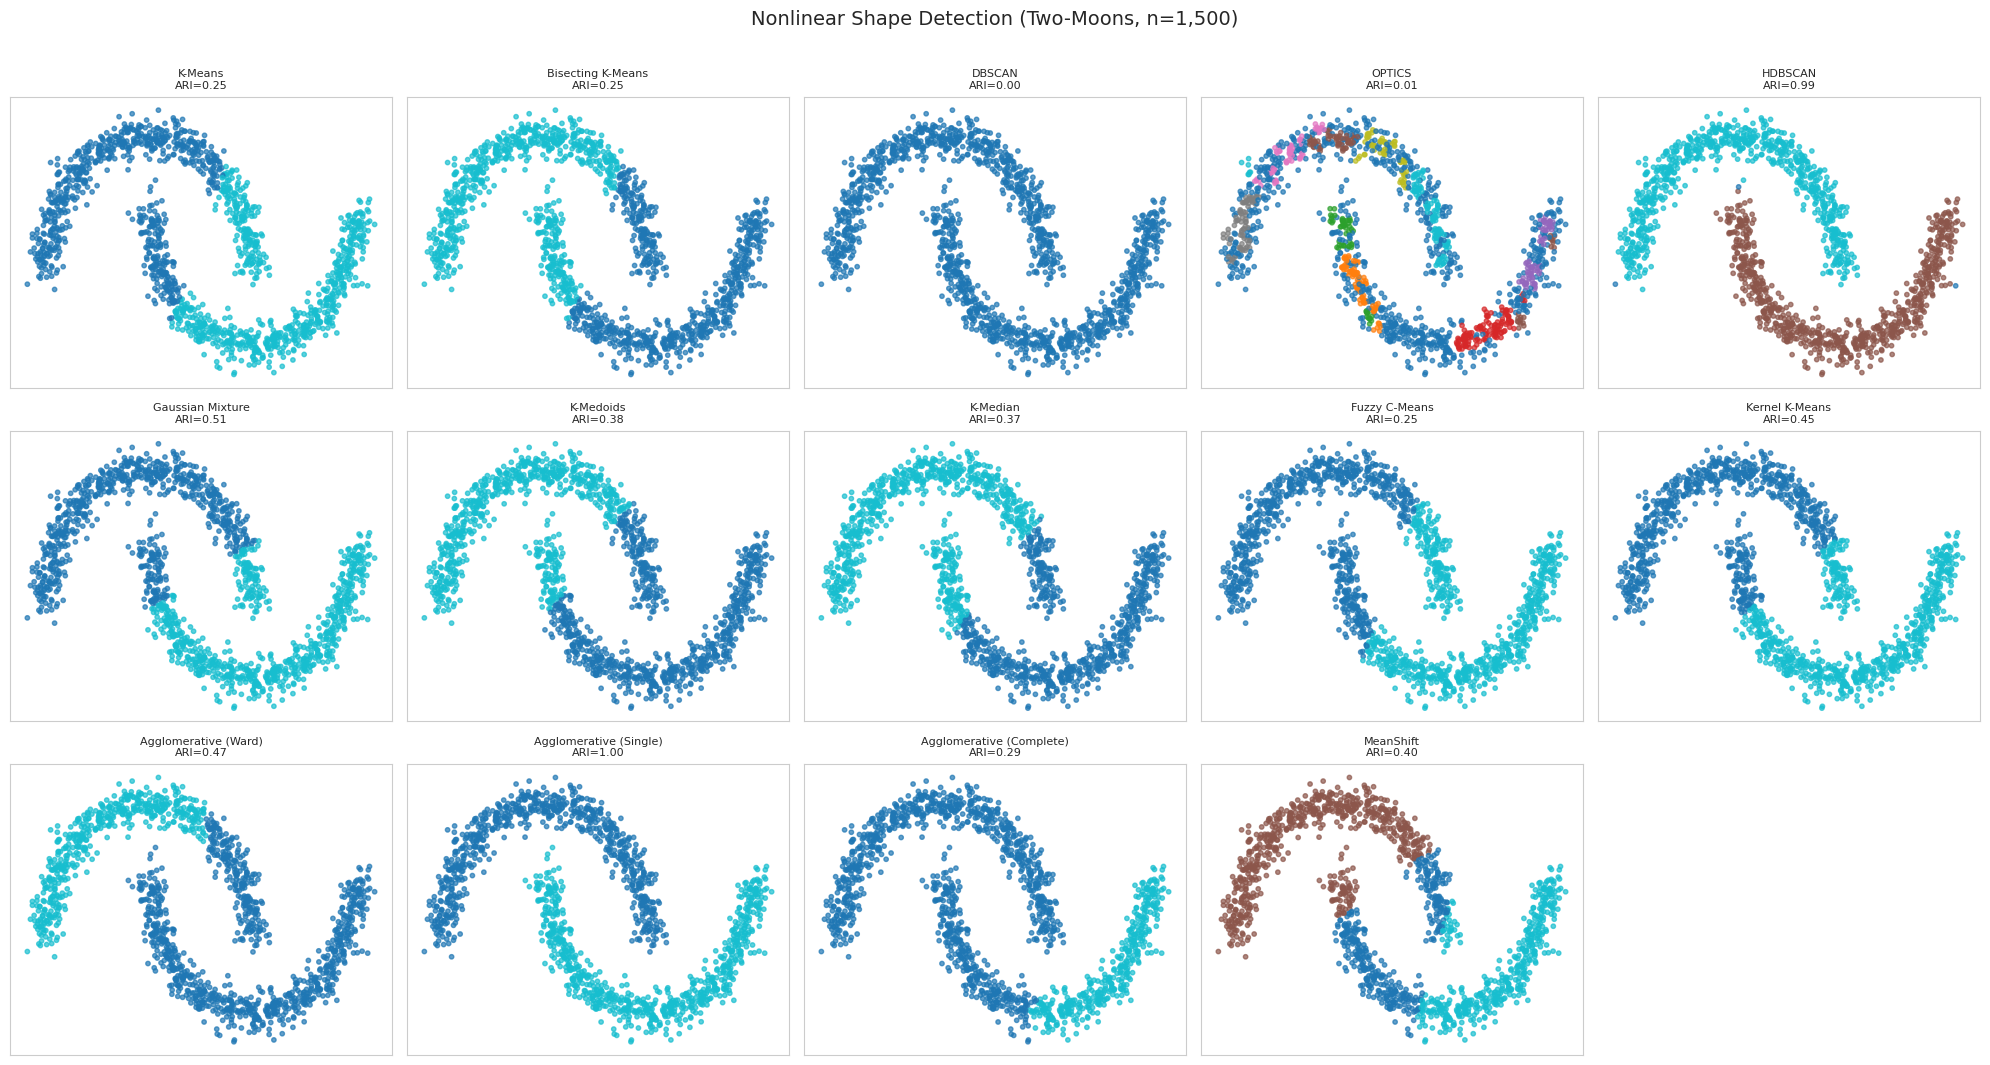


NOISE RESISTANCE EXPERIMENTS
Testing 13 algorithms x 2 noise levels x 2 repeats = 52 refits.

  Testing: K-Means
    noise=5%: ARI=0.864±0.009, time=0.45s
    noise=15%: ARI=0.490±0.200, time=0.21s

  Testing: Bisecting K-Means
    noise=5%: ARI=0.398±0.072, time=0.02s
    noise=15%: ARI=0.162±0.013, time=0.02s

  Testing: K-Medoids
    noise=5%: ARI=0.186±0.083, time=1.07s
    noise=15%: ARI=0.150±0.061, time=1.05s

  Testing: K-Median
    noise=5%: ARI=0.242±0.243, time=0.05s
    noise=15%: ARI=0.198±0.200, time=0.05s

  Testing: Fuzzy C-Means
    noise=5%: ARI=0.269±0.138, time=0.03s
    noise=15%: ARI=0.284±0.031, time=0.06s

  Testing: Kernel K-Means
    noise=5%: ARI=0.157±0.046, time=5.64s
    noise=15%: ARI=0.031±0.047, time=5.78s

  Testing: DBSCAN
    noise=5%: ARI=0.439±0.002, time=0.50s
    noise=15%: ARI=0.295±0.007, time=0.30s

  Testing: OPTICS
    noise=5%: ARI=0.011±0.001, time=7.99s
    noise=15%: ARI=0.015±0.001, time=7.84s

  Testing: HDBSCAN
    noise=5%: ARI=0.58

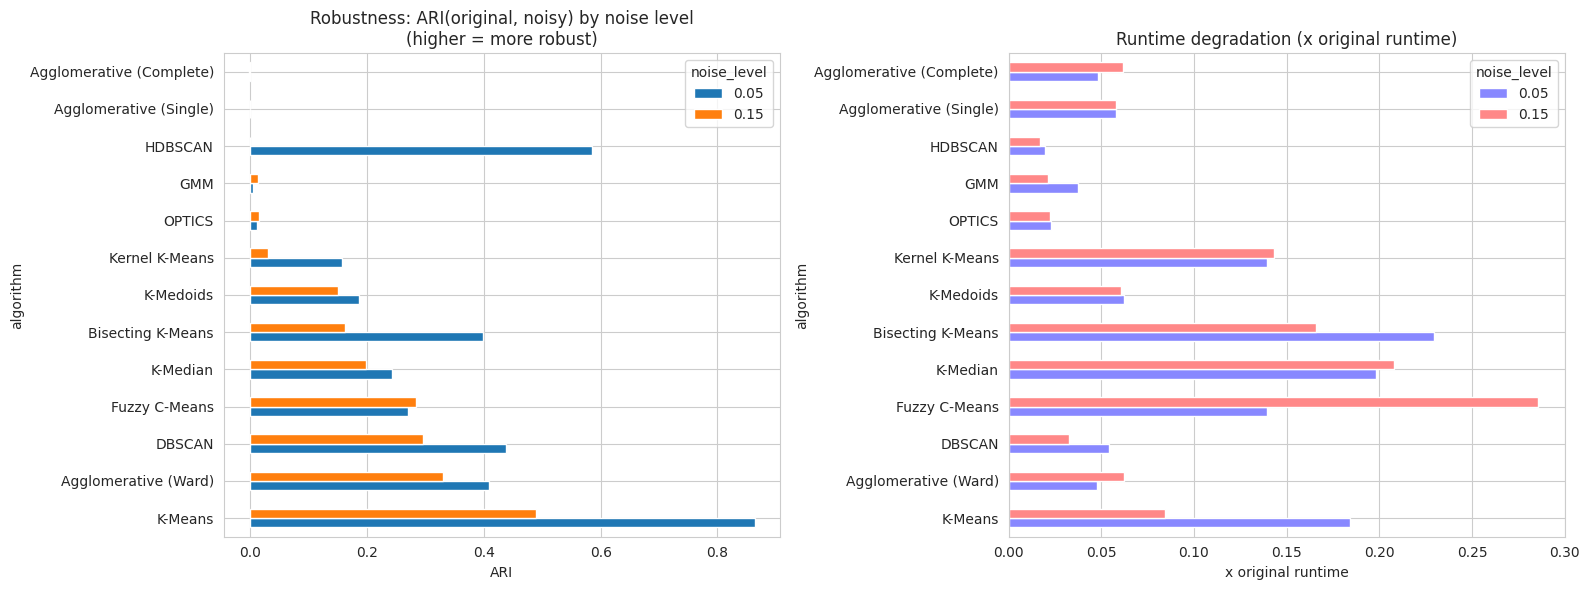


Holistically best model: K-Means

Metrics for best model:
n_clusters              3.000000
noise_pct               0.000000
silhouette              0.117931
davies_bouldin          2.430272
calinski_harabasz    4642.508294
dunn                    0.015336
runtime_s               2.468515
Name: K-Means, dtype: float64

Full ranked comparison:
                          n_clusters  noise_pct  silhouette  davies_bouldin  \
Agglomerative (Single)           3.0  55.762978    0.162041        0.664947   
HDBSCAN                         25.0  90.285550    0.161014        1.736977   
Agglomerative (Ward)             3.0  55.762978    0.091588        2.527623   
K-Means                          3.0   0.000000    0.117931        2.430272   
Bisecting K-Means                3.0   0.000000    0.083562        2.702431   
OPTICS                         196.0  91.072969    0.283283        1.201036   
DBSCAN                          48.0  35.239212   -0.276315        1.271699   
Kernel K-Means         

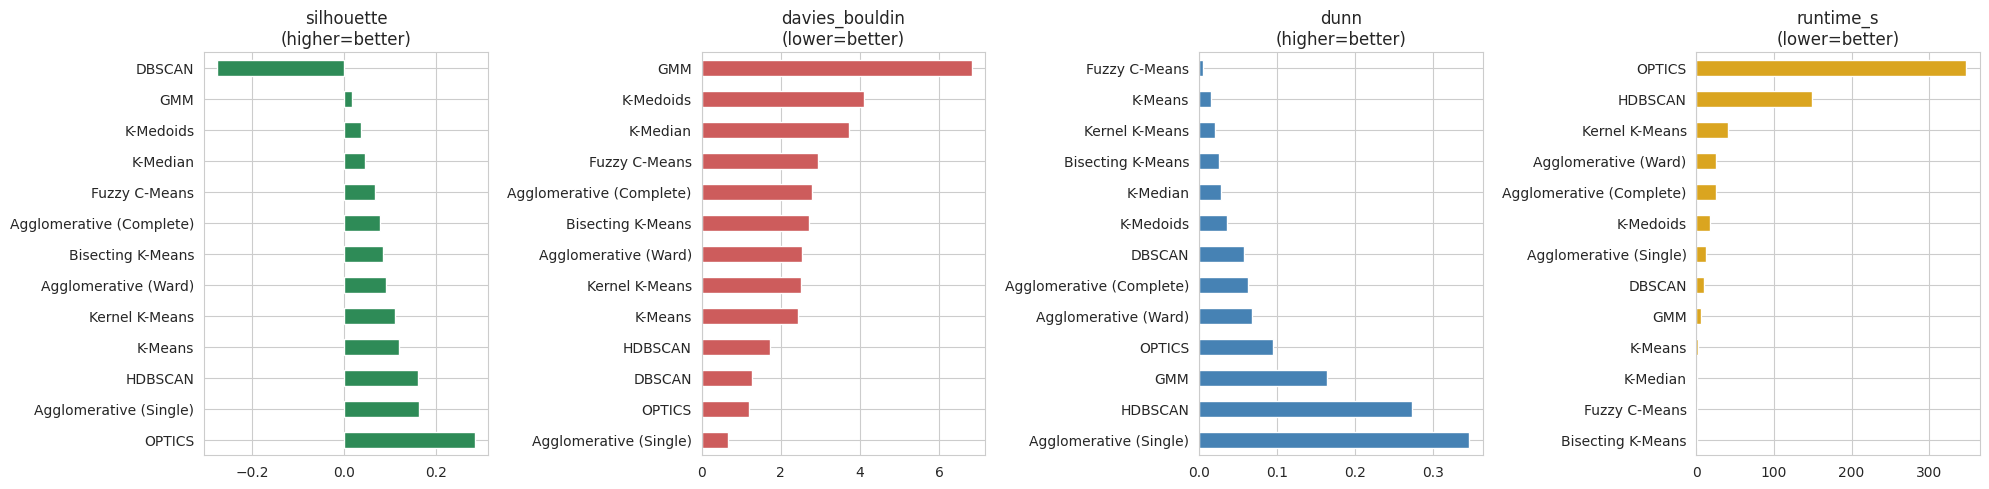

['/content/DataMining_Clustering_Classification/figures/clustering_results/algorithm_comparison.png']

In [12]:
# ============================================================================
# B.4 Comprehensive Algorithm Comparison
# - Internal Quality: Silhouette, Davies-Bouldin, Dunn
# - Practicality: Runtime
# - Nonlinear Detection: Two-Moons ARI
# - Robustness: Noise ARI (multiple levels)
# - Final Ranking & Best Model Selection
# ============================================================================

print("\n" + "=" * 70)
print("B.4 COMPREHENSIVE ALGORITHM COMPARISON")
print("=" * 70)

comparator = ClusteringComparator(X_full, labels_dict, runtimes, verbose=True)

# Existing internal-metric comparison
clustering_comparison_df = comparator.compute_metrics_all()

print("\nComparison results:")
print(clustering_comparison_df[['n_clusters', 'noise_pct', 'silhouette', 'davies_bouldin', 'dunn', 'runtime_s']].head())

# NEW: Nonlinear shape detection (Two-Moons) -- tests whether each algorithm
# can recover non-linear, interlocking structures that centroid-based
# methods typically cannot capture. Runs on its own small synthetic
# two-moons sample (n=1500), so it doesn't touch X_full.
nonlinear_results = comparator.evaluate_nonlinear_shapes(verbose=True)
plt.show()

# NEW: Noise resistance experiments -- refits each algorithm on noisy
# versions of the data (5%, 15% noise) to measure stability and runtime
# degradation, informing which algorithms are safe for production use
# where data quality varies.
#
# NOTE: refitting on the FULL dataset was crashing Colab on memory.
# This step does 13 algorithms x 2 noise levels x 2 repeats = 52 refits,
# and several of those algorithms (Agglomerative, Kernel K-Means,
# K-Medoids, DBSCAN, OPTICS, HDBSCAN) allocate O(n^2) distance/kernel
# matrices -- fine once on X_full, not sustainable 52 times over. So we
# run this part on a smaller subsample instead, using the SAME sampled
# indices for X and the labels so ARI comparisons against the original
# (full-data) labels stay valid.
NOISE_SAMPLE_SIZE = 5000  # lower this further (e.g. 2000) if it still crashes

X_noise_sample, noise_idx = get_sample(X_full, NOISE_SAMPLE_SIZE, RANDOM_STATE)
labels_dict_noise_sample = {
    name: np.asarray(labels)[noise_idx] for name, labels in labels_dict.items()
}

noise_comparator = ClusteringComparator(
    X_noise_sample, labels_dict_noise_sample, runtimes, verbose=True
)
noise_results = noise_comparator.evaluate_noise_resistance(
    noise_levels=[0.05, 0.15], repeats=2, verbose=True
)
plt.show()

# Feed the noise-robustness results (computed on the sample) back into
# the main comparator so holistic_best_model / rank_algorithms below
# use them exactly as before.
comparator.noise_results = noise_results

# Holistic ranking, now incorporating nonlinear detection and noise robustness
best_clustering_model = comparator.holistic_best_model(include_nonlinear=True, include_noise=True)
print(f"\nHolistically best model: {best_clustering_model}")
print(f"\nMetrics for best model:")
print(clustering_comparison_df.loc[best_clustering_model])

# Full multi-metric ranking table (internal quality + nonlinear ARI + noise robustness)
ranked_df = comparator.rank_algorithms(include_nonlinear=True, include_noise=True)
print("\nFull ranked comparison:")
print(ranked_df)

# Plot comparison
fig = comparator.plot_comparison()
plt.show()
save_all_figures({'algorithm_comparison': fig}, subdir='clustering_results')


## B.5 Cluster Profiling


B.5 CLUSTER PROFILING
Profiling 3 clusters with 45,211 points

CLUSTER PROFILING REPORT

Number of Clusters: 3
Total Points: 45,211
Noise Points: 0 (0.0%)

Cluster Summary:
 cluster  count  percentage  age_mean  balance_mean  day_mean  duration_mean  campaign_mean
       0  26481   58.572029 39.492340    379.940613 14.531985     250.033463       1.647710
       1   9499   21.010374 41.628319    599.432678 19.318851     179.278168       4.976945
       2   9231   20.417597 45.379948   2907.662109 15.704195     262.616516       2.001300

Numerical Profiles:
          age_mean    age_std  age_median   age_min  age_max  balance_mean  balance_std  balance_median  balance_min  balance_max   day_mean   day_std  day_median  day_min  day_max  duration_mean  duration_std  duration_median  duration_min  duration_max  campaign_mean  campaign_std  campaign_median  campaign_min  campaign_max
cluster                                                                                                     

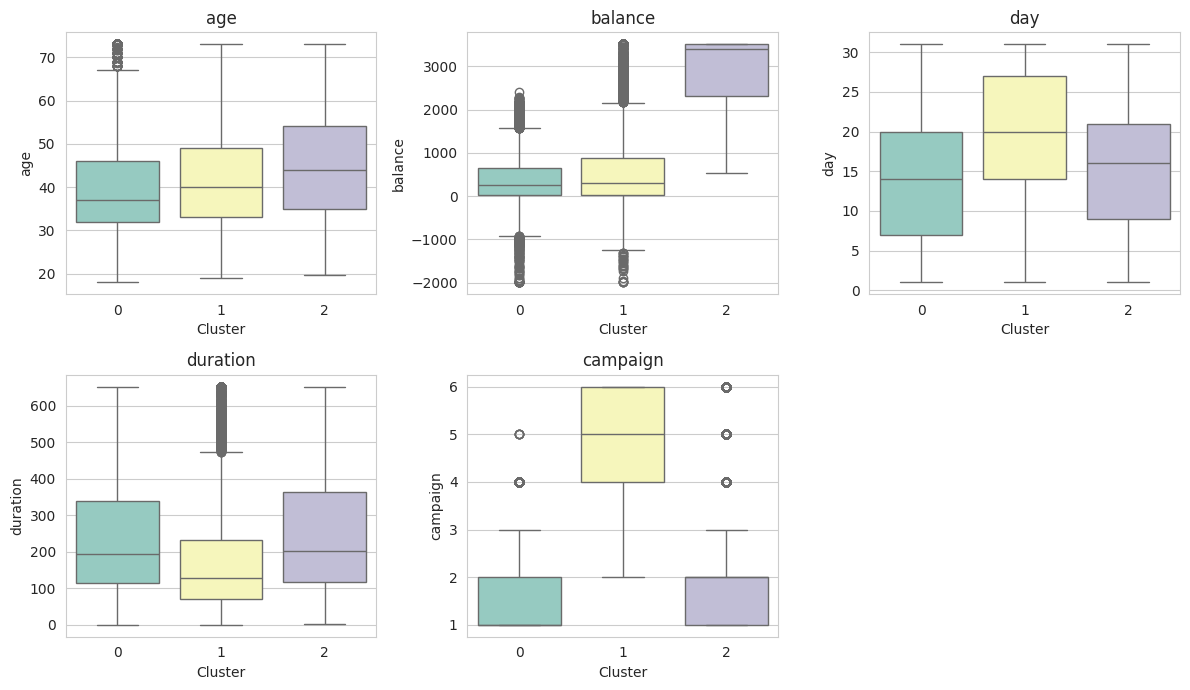

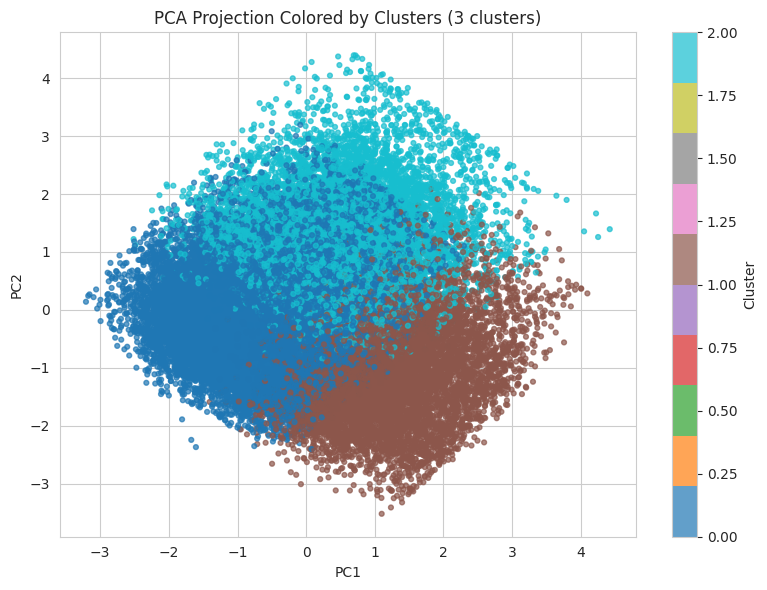

['/content/DataMining_Clustering_Classification/figures/clustering_results/profiles.png',
 '/content/DataMining_Clustering_Classification/figures/clustering_results/pca_colored.png']

In [13]:
# ============================================================================
# B.5 Cluster Profiling (Best Model Only)
# - Numerical Analysis: Means, Medians, Distributions
# - Categorical Analysis: Frequencies, Percentages
# - Feature Importance
# - PCA Visualization (All Clusters Shown)
# ============================================================================

print("\n" + "=" * 70)
print("B.5 CLUSTER PROFILING")
print("=" * 70)

best_labels = labels_dict[best_clustering_model]

profiler = ClusterProfiler(
    df.iloc[:len(best_labels)],
    best_labels,
    feature_columns=NUM_COLS + CAT_COLS,
    num_cols=NUM_COLS,
    cat_cols=CAT_COLS,
    verbose=True
)

print(profiler.get_report())

# Plot numerical profiles
fig_profiles = profiler.plot_numerical()
plt.show()

# Plot PCA colored by clusters (ALL clusters shown)
fig_pca = profiler.plot_pca(X_pca_full[:len(best_labels)])
plt.show()

save_all_figures(
    {'profiles': fig_profiles, 'pca_colored': fig_pca},
    subdir='clustering_results'
)

## B.6 Feature Removal Analysis

In [14]:
# ============================================================================
# B.6 Feature Removal (Using Best Algorithm)
# ============================================================================

print("\n" + "=" * 70)
print("B.6 FEATURE REMOVAL ANALYSIS")
print("=" * 70)

# Get the best algorithm's class from labels_dict
from sklearn.cluster import KMeans

def evaluate_feature_removal(X_full, labels, feature_names, k):
    """Evaluate impact of removing each feature."""
    results = []
    base_score = compute_clustering_metrics(X_full, labels)

    for i, name in enumerate(feature_names):
        X_reduced = np.delete(X_full, i, axis=1)
        # Re-cluster with reduced features
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE)
        labels_reduced = model.fit_predict(X_reduced)
        score = compute_clustering_metrics(X_reduced, labels_reduced)

        results.append({
            'feature_removed': name,
            'silhouette_change': score['silhouette'] - base_score['silhouette'],
            'davies_bouldin_change': score['davies_bouldin'] - base_score['davies_bouldin']
        })

    return pd.DataFrame(results).sort_values('silhouette_change')

# Get feature names
feature_names = X_cluster_df.columns.tolist()
print(f"Evaluating impact of removing {len(feature_names)} features...")

feature_removal_results = evaluate_feature_removal(
    X_full, best_labels, feature_names, best_k
)

print("\nTop 5 features whose removal most hurts silhouette score:")
print(feature_removal_results.head())

print("\nTop 5 features whose removal improves silhouette score:")
print(feature_removal_results.tail())


B.6 FEATURE REMOVAL ANALYSIS
Evaluating impact of removing 14 features...

Top 5 features whose removal most hurts silhouette score:
   feature_removed  silhouette_change  davies_bouldin_change
6          housing          -0.029065               0.438598
13        poutcome          -0.021865               0.283315
0              age          -0.020439               0.279664
10           month          -0.009135               0.132398
5          balance          -0.008164               0.122020

Top 5 features whose removal improves silhouette score:
  feature_removed  silhouette_change  davies_bouldin_change
9             day           0.002054              -0.027928
1             job           0.002715              -0.036473
4         default           0.009320              -0.096582
3       education           0.013040              -0.141168
2         marital           0.014658              -0.150300


---

# PART C — Classification Experiments

## C.1 Target Selection & Train/Test Split

In [15]:
# ============================================================================
# C.1 Target Selection & Train/Test Split (Stratified)
# ============================================================================

print("\n" + "=" * 70)
print("C.1 TARGET SELECTION & TRAIN/TEST SPLIT")
print("=" * 70)

X_train, y_train, X_test, y_test, preprocessor_clf = prepare_classification_data(
    df, verbose=True
)

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Class distribution in train:\n{pd.Series(y_train).value_counts(normalize=True)}")


C.1 TARGET SELECTION & TRAIN/TEST SPLIT
Classification data shape: (42856, 15)
Class distribution:
y
0    37832
1     5024
Name: count, dtype: int64
Class proportions:
y
0    0.88277
1    0.11723
Name: proportion, dtype: float64
Train: 34,284, Test: 8,572
Train class distribution:
y
0    0.882773
1    0.117227
Name: proportion, dtype: float64
Test class distribution:
y
0    0.882758
1    0.117242
Name: proportion, dtype: float64

Train shape: (34284, 14)
Test shape: (8572, 14)
Class distribution in train:
y
0    0.882773
1    0.117227
Name: proportion, dtype: float64


## C.2 Feature Preprocessing

In [16]:
# ============================================================================
# C.2 Feature Preprocessing (Scaling, Encoding, Transformation)
# ============================================================================

print("\n" + "=" * 70)
print("C.2 FEATURE PREPROCESSING")
print("=" * 70)

X_train_enc = preprocessor_clf.fit_transform(X_train).astype(np.float64)
X_test_enc = preprocessor_clf.transform(X_test).astype(np.float64)

print(f"Train encoded shape: {X_train_enc.shape}")
print(f"Test encoded shape: {X_test_enc.shape}")
print(f"Encoded dtype: {X_train_enc.dtype}")
print(f"Memory usage (train): {X_train_enc.nbytes / 1024**2:.2f} MB")
print(f"Memory usage (test): {X_test_enc.nbytes / 1024**2:.2f} MB")

print("\nPreprocessing pipeline saved for consistent transformation.")


C.2 FEATURE PREPROCESSING
Train encoded shape: (34284, 47)
Test encoded shape: (8572, 47)
Encoded dtype: float64
Memory usage (train): 12.29 MB
Memory usage (test): 3.07 MB

Preprocessing pipeline saved for consistent transformation.


## C.3 Base Classifiers

In [17]:
# ============================================================================
# C.3 Base Classifiers (Cross-Validation Primary)
# - Logistic Regression
# - Decision Tree
# - Naive Bayes
# - Neural Network (PyTorch, 2-3 Hidden Layers, ReLU, Sigmoid, Adam, BCE)
# ============================================================================

print("\n" + "=" * 70)
print("C.3 BASE CLASSIFIERS")
print("=" * 70)

classifiers = create_all_base_classifiers(use_gridsearch=True)
classification_results = []

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    metrics = train_and_evaluate_classifier(
        clf, X_train_enc, y_train, X_test_enc, y_test, verbose=True
    )
    classification_results.append(metrics)

classification_df = pd.DataFrame(classification_results)
classification_df = classification_df.set_index('model')

print("\n" + "=" * 50)
print("Base Classifier Results:")
print("=" * 50)
print(classification_df[['accuracy', 'precision', 'recall', 'f1', 'auc_roc']])


C.3 BASE CLASSIFIERS

Training Logistic Regression...
Logistic Regression: Running GridSearch with 5-fold CV...
Logistic Regression: Best params: {'clf__C': 0.1}
Logistic Regression: Best CV F1: 0.485
Logistic Regression: Training completed in 5.35s

Logistic Regression Results:
  F1: 0.486
  AUC-ROC: 0.874
  Accuracy: 0.805
  Precision: 0.352
  Recall: 0.787
  Training time: 5.35s

Training Decision Tree...
Decision Tree: Running GridSearch with 5-fold CV...
Decision Tree: Best params: {'clf__max_depth': 7, 'clf__min_samples_split': 2}
Decision Tree: Best CV F1: 0.448
Decision Tree: Training completed in 6.47s

Decision Tree Results:
  F1: 0.430
  AUC-ROC: 0.847
  Accuracy: 0.738
  Precision: 0.289
  Recall: 0.843
  Training time: 6.47s

Training Naive Bayes...
Naive Bayes: Training completed in 0.02s

Naive Bayes Results:
  F1: 0.370
  AUC-ROC: 0.775
  Accuracy: 0.861
  Precision: 0.396
  Recall: 0.347
  Training time: 0.02s

Training Random Forest...
Random Forest: Running GridSear

### Neural Network (PyTorch)


----------------------------------------
Neural Network (PyTorch):
----------------------------------------
Epoch 10/50 - Train Loss: 0.2405, Val Loss: 0.2387
Epoch 20/50 - Train Loss: 0.2318, Val Loss: 0.2386
Epoch 30/50 - Train Loss: 0.2231, Val Loss: 0.2355
Early stopping at epoch 33

Neural Network Results:
  F1: 0.421
  AUC: 0.893


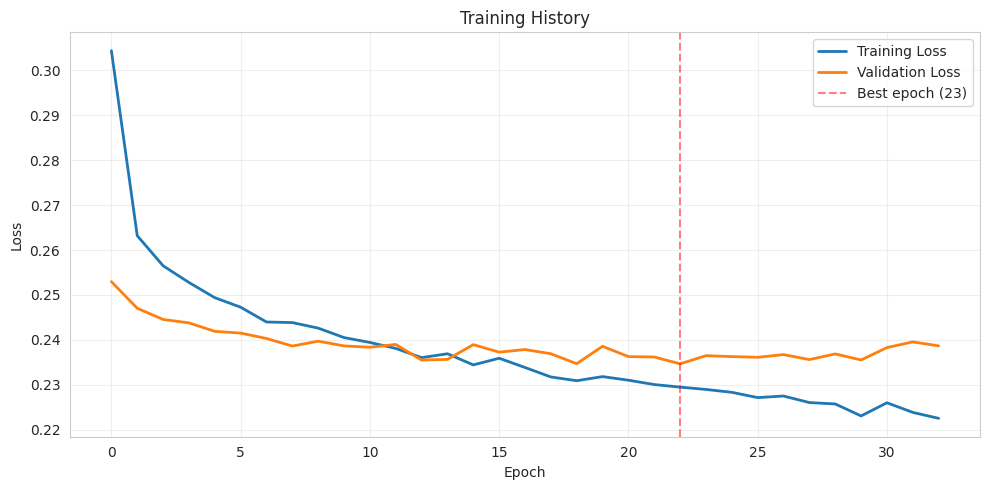

In [18]:
# ============================================================================
# Neural Network: PyTorch Feedforward Network
# - 2-3 Hidden Layers, ReLU Activation, Sigmoid Output
# - Adam Optimizer, Binary Cross-Entropy Loss
# - GPU with CPU fallback
# ============================================================================

print("\n" + "-" * 40)
print("Neural Network (PyTorch):")
print("-" * 40)

try:
    nn_model = create_neural_network(
        hidden_dims=[64, 32, 16],
        epochs=50,
        batch_size=64,
        verbose=True
    )

    nn_model.fit(X_train_enc, y_train.values)

    y_pred_nn = nn_model.predict(X_test_enc)
    y_proba_nn = nn_model.predict_proba(X_test_enc)[:, 1]

    nn_metrics = compute_classification_metrics(y_test, y_pred_nn, y_proba_nn)
    nn_metrics['train_time_s'] = getattr(nn_model, 'train_time_', 0)

    classification_df.loc['Neural Network'] = pd.Series(nn_metrics)

    print(f"\nNeural Network Results:")
    print(f"  F1: {nn_metrics['f1']:.3f}")
    print(f"  AUC: {nn_metrics['auc_roc']:.3f}")

    fig = nn_model.plot_training_history()
    plt.show()

except Exception as e:
    print(f"Neural Network not available: {e}")
    print("Skipping neural network.")

## C.4 Ensemble Methods

In [19]:
# ============================================================================
# C.4 Ensemble Methods
# - Bagging: Random Forest, Manual Bagging
# - Boosting: XGBoost, Manual Boosting + Depth Analysis
# ============================================================================

print("\n" + "=" * 70)
print("C.4 ENSEMBLE METHODS")
print("=" * 70)

# XGBoost
print("\n" + "-" * 40)
print("XGBoost:")
print("-" * 40)

try:
    import xgboost as xgb

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss',
        device=XGB_DEVICE
    )

    xgb_model.fit(X_train_enc, y_train)
    y_pred_xgb = xgb_model.predict(X_test_enc)
    y_proba_xgb = xgb_model.predict_proba(X_test_enc)[:, 1]

    xgb_metrics = compute_classification_metrics(y_test, y_pred_xgb, y_proba_xgb)
    classification_df.loc['XGBoost'] = pd.Series(xgb_metrics)

    print(f"XGBoost Results:")
    print(f"  F1: {xgb_metrics['f1']:.3f}")
    print(f"  AUC: {xgb_metrics['auc_roc']:.3f}")

except Exception as e:
    print(f"XGBoost not available: {e}")

# Manual Bagging
print("\n" + "-" * 40)
print("Manual Bagging:")
print("-" * 40)

proba_bag, pred_bag = manual_bagging(
    X_train_enc, y_train.values, X_test_enc,
    n_estimators=15,
    verbose=True
)

bag_metrics = compute_classification_metrics(y_test, pred_bag, proba_bag)
classification_df.loc['Manual Bagging'] = pd.Series(bag_metrics)
print(f"\nManual Bagging Results:")
print(f"  F1: {bag_metrics['f1']:.3f}")
print(f"  AUC: {bag_metrics['auc_roc']:.3f}")

# Manual Boosting (AdaBoost)
print("\n" + "-" * 40)
print("Manual AdaBoost:")
print("-" * 40)

proba_boost, pred_boost, models, alphas = manual_adaboost(
    X_train_enc, y_train.values, X_test_enc,
    n_iterations=40,
    base_max_depth=1,
    verbose=True
)

boost_metrics = compute_classification_metrics(y_test, pred_boost, proba_boost)
classification_df.loc['Manual AdaBoost'] = pd.Series(boost_metrics)
print(f"\nManual AdaBoost Results:")
print(f"  F1: {boost_metrics['f1']:.3f}")
print(f"  AUC: {boost_metrics['auc_roc']:.3f}")


C.4 ENSEMBLE METHODS

----------------------------------------
XGBoost:
----------------------------------------
XGBoost Results:
  F1: 0.406
  AUC: 0.910

----------------------------------------
Manual Bagging:
----------------------------------------
Manual Bagging: Training 15 base learners...
  Trained 5/15 learners
  Trained 10/15 learners
  Trained 15/15 learners

Manual Bagging Results:
  F1: 0.506
  AUC: 0.891

----------------------------------------
Manual AdaBoost:
----------------------------------------
Manual AdaBoost: Training 40 iterations with depth=1
  Iteration 10/40: error=0.4820, alpha=0.0360
  Iteration 20/40: error=0.4615, alpha=0.0771
  Iteration 30/40: error=0.4887, alpha=0.0225
  Iteration 40/40: error=0.4871, alpha=0.0258

Manual AdaBoost Results:
  F1: 0.300
  AUC: 0.857


### Boosting Depth Experiment


----------------------------------------
Manual Boosting Depth Analysis:
----------------------------------------

Testing depth=1...
  F1: 0.300, AUC: 0.857, time: 1.1s

Testing depth=2...
  F1: 0.330, AUC: 0.878, time: 2.0s

Testing depth=3...
  F1: 0.364, AUC: 0.894, time: 3.5s

Testing depth=5...
  F1: 0.419, AUC: 0.892, time: 4.1s

Testing depth=7...
  F1: 0.442, AUC: 0.889, time: 5.7s

Depth Experiment Results:
               base_learner  depth        f1   auc_roc  train_time_s  \
0  Decision Stump (depth=1)      1  0.299578  0.857028      1.139533   
1                   Depth 2      2  0.329655  0.878416      2.006175   
2                   Depth 3      3  0.364486  0.893934      3.485414   
3                   Depth 5      5  0.418633  0.891975      4.138088   
4                   Depth 7      7  0.441753  0.889252      5.659436   

   n_learners  
0          40  
1          40  
2          40  
3          40  
4          40  


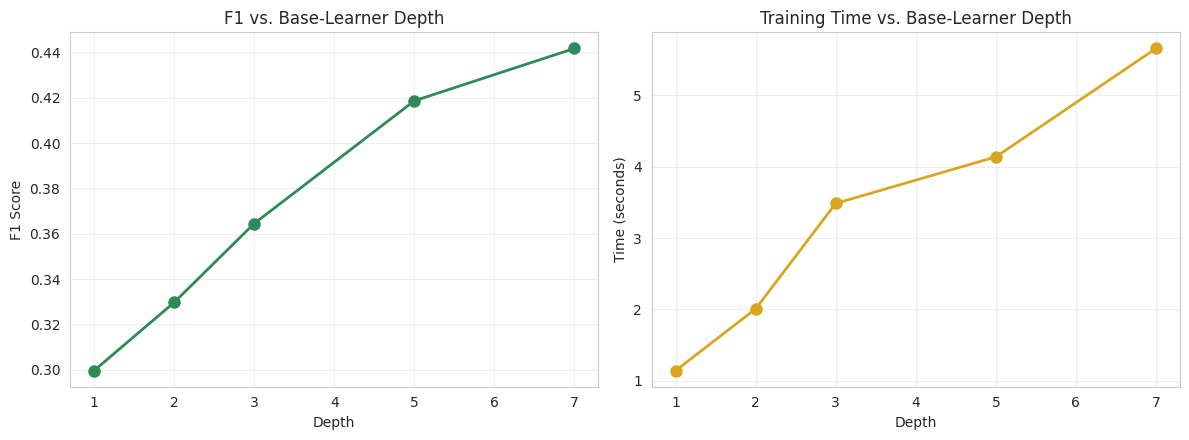

In [20]:
# ============================================================================
# Manual Boosting Depth Analysis
# ============================================================================

print("\n" + "-" * 40)
print("Manual Boosting Depth Analysis:")
print("-" * 40)

depth_results = run_boosting_depth_experiment(
    X_train_enc, y_train.values, X_test_enc, y_test,
    depths=[1, 2, 3, 5, 7],
    n_iterations=40,
    verbose=True
)

print("\nDepth Experiment Results:")
print(depth_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(depth_results['depth'], depth_results['f1'], 'o-',
             color='seagreen', linewidth=2, markersize=8)
axes[0].set_title("F1 vs. Base-Learner Depth", fontsize=12)
axes[0].set_xlabel("Depth", fontsize=10)
axes[0].set_ylabel("F1 Score", fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(depth_results['depth'], depth_results['train_time_s'], 'o-',
             color='goldenrod', linewidth=2, markersize=8)
axes[1].set_title("Training Time vs. Base-Learner Depth", fontsize=12)
axes[1].set_xlabel("Depth", fontsize=10)
axes[1].set_ylabel("Time (seconds)", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## C.5 Results Comparison


C.5 RESULTS COMPARISON

Complete Classification Results:
                     accuracy  precision  recall      f1  auc_roc
model                                                            
Logistic Regression    0.8048     0.3516  0.7871  0.4860   0.8735
Decision Tree          0.7381     0.2887  0.8428  0.4301   0.8468
Naive Bayes            0.8614     0.3961  0.3473  0.3701   0.7752
Random Forest          0.8042     0.3516  0.7930  0.4872   0.8797
Neural Network         0.8857     0.5182  0.3542  0.4208   0.8933
XGBoost                0.8919     0.5701  0.3154  0.4061   0.9105
Manual Bagging         0.8125     0.3661  0.8189  0.5060   0.8909
Manual AdaBoost        0.8838     0.5108  0.2119  0.2996   0.8570

Best classifier: Manual Bagging
Best F1 score: 0.5060


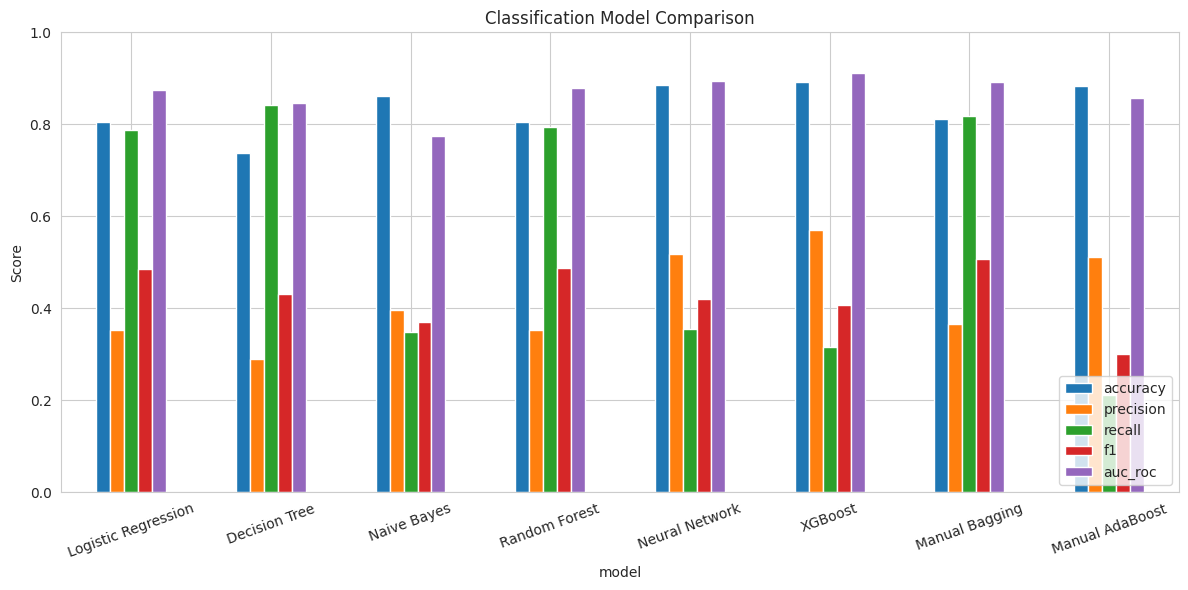

['/content/DataMining_Clustering_Classification/figures/classification/model_comparison.png']

In [21]:
# ============================================================================
# C.5 Results Comparison (Consolidated Table, All Models)
# ============================================================================

print("\n" + "=" * 70)
print("C.5 RESULTS COMPARISON")
print("=" * 70)

print("\nComplete Classification Results:")
print("=" * 50)
print(classification_df[['accuracy', 'precision', 'recall', 'f1', 'auc_roc']].round(4))

# Best model
best_classifier = classification_df['f1'].idxmax()
best_f1 = classification_df.loc[best_classifier, 'f1']
print(f"\nBest classifier: {best_classifier}")
print(f"Best F1 score: {best_f1:.4f}")

# Plot comparison
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
fig, ax = plt.subplots(figsize=(12, 6))
classification_df[metrics_to_plot].plot(kind='bar', ax=ax)
ax.set_title("Classification Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
save_all_figures({'model_comparison': fig}, subdir='classification')

## C.6 Overfitting & Underfitting Analysis


C.6 OVERFITTING & UNDERFITTING ANALYSIS

Analyzing Logistic Regression...
Computing overfitting gap for Logistic Regression...
  Train F1: 0.486
  Validation F1: 0.486
  Gap: 0.000
Computing learning curve for Logistic Regression...


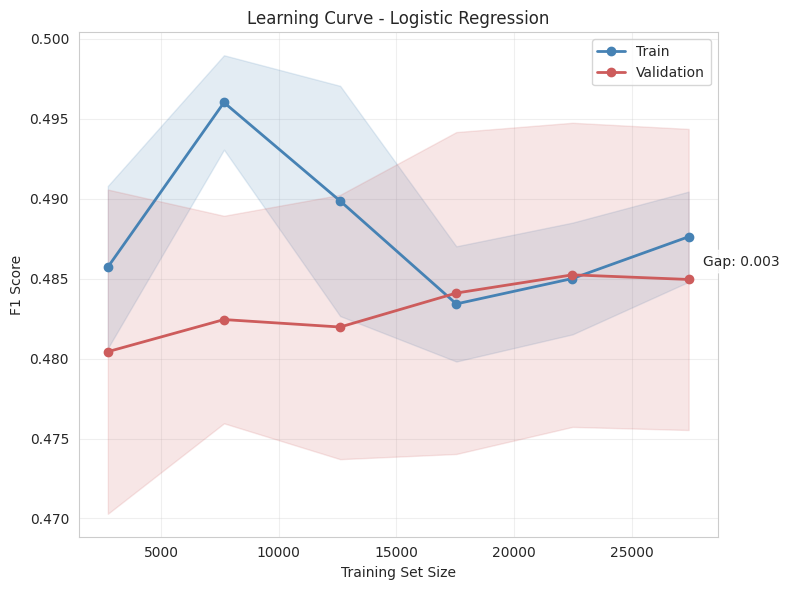


Analyzing Decision Tree...
Computing overfitting gap for Decision Tree...
  Train F1: 0.451
  Validation F1: 0.430
  Gap: 0.021
Computing learning curve for Decision Tree...


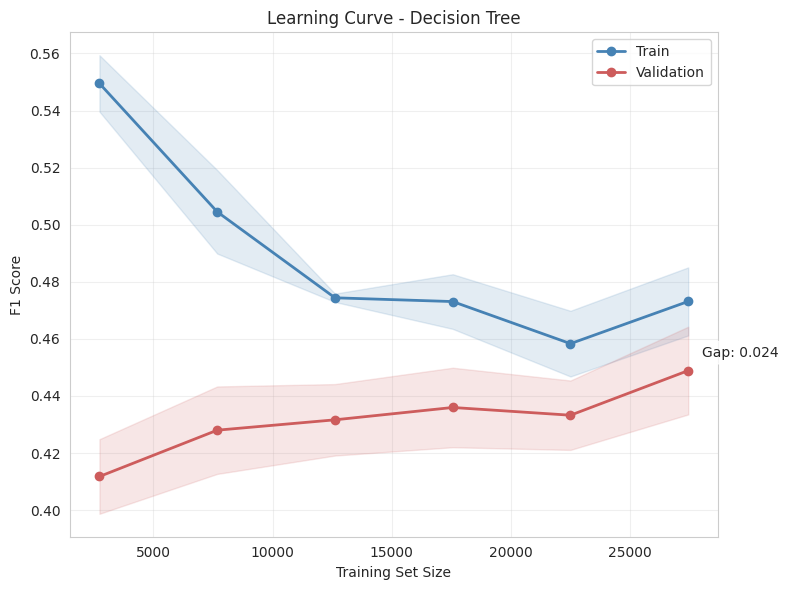


Analyzing Naive Bayes...
Computing overfitting gap for Naive Bayes...
  Train F1: 0.362
  Validation F1: 0.370
  Gap: -0.008
Computing learning curve for Naive Bayes...


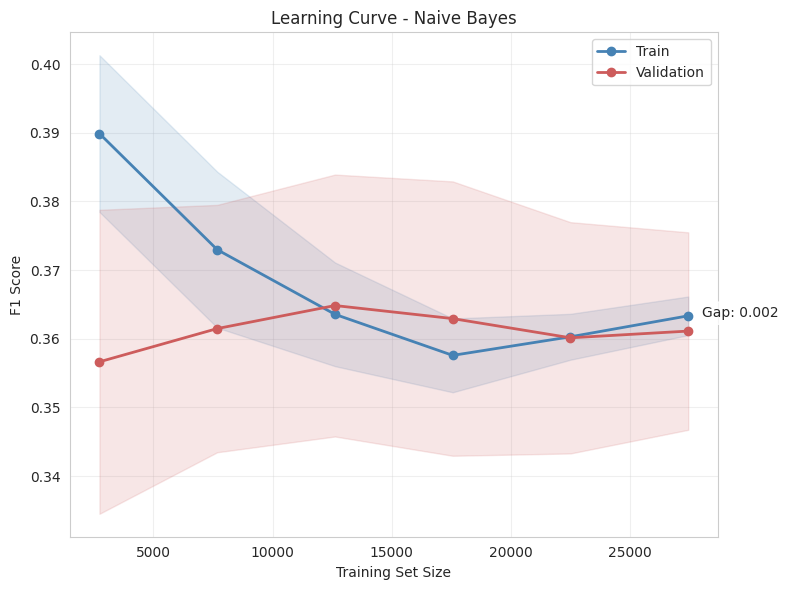


Analyzing Random Forest...
Computing overfitting gap for Random Forest...
  Train F1: 0.536
  Validation F1: 0.487
  Gap: 0.049
Computing learning curve for Random Forest...


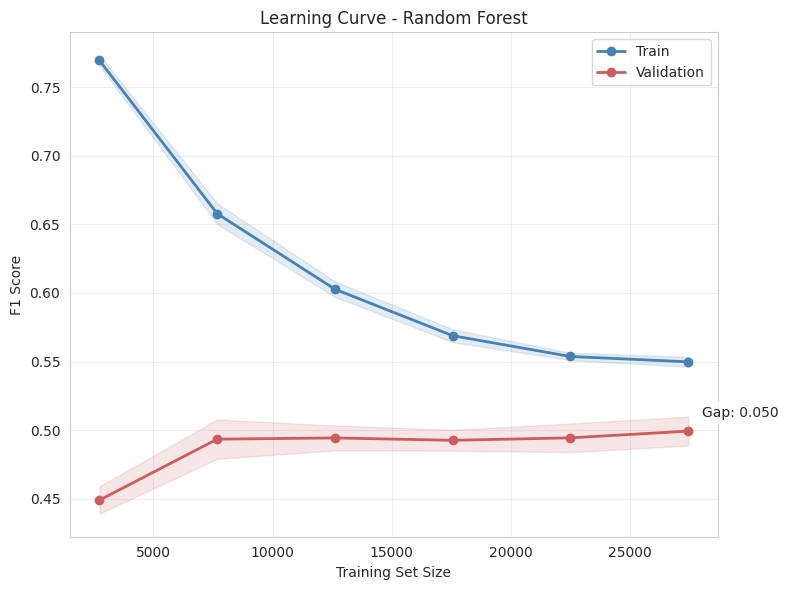


Overfitting Summary:
                 model  train_f1    val_f1  overfitting_gap  is_overfitting
0  Logistic Regression  0.486388  0.486022         0.000367           False
1        Decision Tree  0.451112  0.430058         0.021053           False
2          Naive Bayes  0.361734  0.370095        -0.008362           False
3        Random Forest  0.536312  0.487164         0.049148           False

Interpretation:
  - Logistic Regression: Good generalization (gap = 0.0004)
    Recommendation: Model is well-balanced.
  - Decision Tree: Some overfitting (gap = 0.0211)
    Recommendation: Monitor validation performance.
  - Naive Bayes: Good generalization (gap = -0.0084)
    Recommendation: Model is well-balanced.
  - Random Forest: Some overfitting (gap = 0.0491)
    Recommendation: Monitor validation performance.


In [22]:
# ============================================================================
# C.6 Overfitting & Underfitting Analysis
# - Learning Curves
# - Validation Curves
# - Interpretation (Explanations Required)
# ============================================================================

print("\n" + "=" * 70)
print("C.6 OVERFITTING & UNDERFITTING ANALYSIS")
print("=" * 70)

overfitting_results = []

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Analyzing {name}...")
    print('='*50)

    analyzer = OverfittingAnalyzer(
        clf.pipeline if hasattr(clf, 'pipeline') else clf.model,
        X_train_enc, y_train, X_test_enc, y_test,
        model_name=name,
        verbose=True
    )

    gap = analyzer.compute_gap()
    overfitting_results.append({
        'model': name,
        'train_f1': analyzer.train_f1,
        'val_f1': analyzer.val_f1,
        'overfitting_gap': gap,
        'is_overfitting': analyzer.is_overfitting()
    })

    fig = analyzer.plot_learning_curve()
    plt.show()

overfitting_df = pd.DataFrame(overfitting_results)

print("\n" + "=" * 50)
print("Overfitting Summary:")
print("=" * 50)
print(overfitting_df)

# Interpretation
print("\n" + "=" * 50)
print("Interpretation:")
print("=" * 50)
for _, row in overfitting_df.iterrows():
    model = row['model']
    gap = row['overfitting_gap']
    is_overfit = row['is_overfitting']

    if is_overfit:
        print(f"  - {model}: OVERFITTING detected (gap = {gap:.4f})")
        print(f"    Recommendation: Reduce model complexity or add regularization.")
    elif gap > 0.02:
        print(f"  - {model}: Some overfitting (gap = {gap:.4f})")
        print(f"    Recommendation: Monitor validation performance.")
    else:
        print(f"  - {model}: Good generalization (gap = {gap:.4f})")
        print(f"    Recommendation: Model is well-balanced.")

## C.7 Pre-Call Feature Analysis

In [23]:
# ============================================================================
# C.7 Pre-Call Feature Analysis
# ============================================================================

print("\n" + "=" * 70)
print("C.7 PRE-CALL FEATURE ANALYSIS")
print("=" * 70)

precall_analyzer = PreCallAnalyzer(
    df,
    target_col=TARGET_COL,
    verbose=True
)

precall_results = precall_analyzer.compare_with_xgboost()
print(precall_analyzer.get_report())

# Lift analysis
data = precall_results['data']
X_test_full_enc, X_test_pc_enc, y_test_full, y_test_pc = data
if len(data) == 4:
    X_test_full_enc, X_test_pc_enc, y_test_full, y_test_pc = data

    model_full, model_pc = precall_results['models']
    proba_full = model_full.predict_proba(X_test_full_enc)[:, 1]
    proba_pc = model_pc.predict_proba(X_test_pc_enc)[:, 1]

    y_series = pd.Series(y_test_full)
    lift_full = lift_at_k(y_series, proba_full, k=0.1)
    lift_pc = lift_at_k(y_series, proba_pc, k=0.1)

    print(f"\nLift at 10% (full features): {lift_full:.2f}")
    print(f"Lift at 10% (pre-call only): {lift_pc:.2f}")

    if lift_pc > 1.5:
        print("  -> Pre-call model can effectively prioritize leads.")
    elif lift_pc > 1.2:
        print("  -> Pre-call model has modest prioritization ability.")
    else:
        print("  -> Pre-call model has little prioritization ability.")


C.7 PRE-CALL FEATURE ANALYSIS
Training XGBoost with full features...
Training XGBoost with pre-call features only...

Full features: F1=0.553, AUC=0.908
Pre-call features: F1=0.391, AUC=0.756
Features excluded: ['duration']

PRE-CALL FEATURE ANALYSIS REPORT

Features excluded (post-call): ['duration']

Performance Comparison:
  Full Features:    F1=0.553, AUC=0.908
  Pre-Call Only:    F1=0.391, AUC=0.756

F1 Drop: 0.162 (29.2%)

Interpretation:
  Post-call features (duration) are highly predictive. Pre-call model is significantly weaker.

Practical Implication:
  Pre-call model is not reliable for lead targeting. Consider collecting more pre-call features.


Lift at 10% (full features): 4.61
Lift at 10% (pre-call only): 3.85
  -> Pre-call model can effectively prioritize leads.


---

# PART D — Summary & Conclusions

## D.1 Final Comparison Tables

In [24]:
# ============================================================================
# D.1 Final Comparison Tables
# - Clustering Ranking Table
# - Classification Ranking Table
# ============================================================================

print("\n" + "=" * 70)
print("D.1 FINAL COMPARISON TABLES")
print("=" * 70)

print("\n" + "=" * 50)
print("Clustering Ranking Table:")
print("=" * 50)

clustering_final = clustering_comparison_df.sort_values('silhouette', ascending=False)
display_cols = ['silhouette', 'davies_bouldin', 'dunn', 'runtime_s', 'noise_pct']
print(clustering_final[display_cols].round(4).head(10))

print("\n" + "=" * 50)
print("Classification Ranking Table:")
print("=" * 50)

classification_final = classification_df.sort_values('f1', ascending=False)
display_cols = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
print(classification_final[display_cols].round(4))


D.1 FINAL COMPARISON TABLES

Clustering Ranking Table:
                          silhouette  davies_bouldin    dunn  runtime_s  \
OPTICS                        0.2833          1.2010  0.0954   348.1712   
Agglomerative (Single)        0.1620          0.6649  0.3460    12.1816   
HDBSCAN                       0.1610          1.7370  0.2724   149.0903   
K-Means                       0.1179          2.4303  0.0153     2.4685   
Kernel K-Means                0.1102          2.5090  0.0210    40.3648   
Agglomerative (Ward)          0.0916          2.5276  0.0679    25.4894   
Bisecting K-Means             0.0836          2.7024  0.0252     0.1048   
Agglomerative (Complete)      0.0785          2.7964  0.0625    25.1701   
Fuzzy C-Means                 0.0670          2.9472  0.0053     0.2125   
K-Median                      0.0460          3.7163  0.0279     0.2518   

                          noise_pct  
OPTICS                      91.0730  
Agglomerative (Single)      55.7630  
HDBS

## D.2 Extrinsic Evaluation

In [25]:
# ============================================================================
# D.2 Extrinsic Evaluation (Clustering vs Classification)
# ============================================================================

print("\n" + "=" * 70)
print("D.2 EXTRINSIC EVALUATION")
print("=" * 70)

extrinsic_results = compute_extrinsic_evaluation(
    df,
    best_labels,
    target_col=TARGET_COL,
    algorithm_name=best_clustering_model,
    verbose=True
)

best_f1 = classification_df['f1'].max()
interpretation = interpret_extrinsic_evaluation(extrinsic_results, best_f1)

print("\n" + "=" * 50)
print("Interpretation:")
print("=" * 50)
for key, value in interpretation.items():
    print(f"\n{key.replace('_', ' ').title()}:")
    print(f"  {value}")


D.2 EXTRINSIC EVALUATION

Extrinsic Evaluation: K-Means
  ARI (vs. subscription): 0.000
  NMI (vs. subscription): 0.002
  Number of clusters: 3

  Subscription rate per cluster:
    Cluster 2: 14.33%
    Cluster 0: 11.79%
    Cluster 1: 9.17%

Interpretation:

Ari Interpretation:
  Clusters do NOT align with subscription behavior. Subscription is driven by behavioral factors (like duration), not static customer characteristics.

Combined Interpretation:
  Clustering does NOT predict subscription, but classification does. This suggests subscription is driven by behavioral signals (e.g., call duration), not customer demographics.

Practical Implication:
  Moderate variation in subscription rates across clusters (1.6x difference). Some targeting potential exists.


## D.3 Final Discussion

In [26]:
# ============================================================================
# D.3 Final Discussion
# - Practical Recommendations
# - Limitations
# - Future Work
# ============================================================================

print("\n" + "=" * 70)
print("D.3 FINAL DISCUSSION")
print("=" * 70)

clustering_metrics = clustering_comparison_df.loc[best_clustering_model].to_dict()
classification_metrics = classification_df.loc[best_classifier].to_dict()

discussion = generate_final_discussion(
    clustering_best=best_clustering_model,
    classification_best=best_classifier,
    clustering_metrics=clustering_metrics,
    classification_metrics=classification_metrics,
    extrinsic_results=extrinsic_results,
    feature_importance=None
)

print(discussion)

# Save discussion
os.makedirs("./reports", exist_ok=True)
with open("./reports/final_discussion.txt", "w") as f:
    f.write(discussion)
print("\nDiscussion saved to: ./reports/final_discussion.txt")


D.3 FINAL DISCUSSION
FINAL DISCUSSION

### Best Clustering Algorithm

The holistic selection process identified **K-Means** as the best clustering algorithm.
  - Silhouette Score: 0.118
  - Davies-Bouldin: 2.430
  - Number of Clusters: 3.0
  - Noise Percentage: 0.0%

### Best Classification Model

The best classification model is **Manual Bagging**.
  - F1 Score: 0.506
  - AUC-ROC: 0.891
  - Accuracy: 0.813

### Extrinsic Evaluation

Clustering vs. Subscription Alignment:
  - ARI: 0.000
  - NMI: 0.002

Subscription rates by cluster:
  - Cluster 2: 14.33%
  - Cluster 0: 11.79%
  - Cluster 1: 9.17%

### Key Findings

1. **Clustering Performance:**
   The selected clustering algorithm demonstrates good internal validity
   with reasonable cluster separation and compactness.

2. **Classification Performance:**
   The best classifier achieves F1=0.506,
   indicating strong predictive power.

### Practical Recommendations

1. **Use the full dataset** (or as large a sample as computationally

## Project Completion

In [27]:
# ============================================================================
# Project Completion Summary
# ============================================================================

print("\n" + "=" * 70)
print("PROJECT 3 COMPLETED SUCCESSFULLY!")
print("=" * 70)
print(f"\nDataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Clustering algorithms evaluated: {len(labels_dict)}")
print(f"Classification models evaluated: {len(classification_df)}")
print(f"\nBest clustering algorithm: {best_clustering_model}")
print(f"Best classifier: {best_classifier}")
print(f"\nExtrinsic ARI: {extrinsic_results['ari']:.3f}")
print(f"Extrinsic NMI: {extrinsic_results['nmi']:.3f}")
print("\n" + "=" * 70)
print("All outputs saved to:")
print("  - reports/project_summary.txt")
print("  - reports/final_discussion.txt")
print("  - figures/ (all plots)")
print("=" * 70)


PROJECT 3 COMPLETED SUCCESSFULLY!

Dataset: 45,211 rows, 15 columns
Clustering algorithms evaluated: 13
Classification models evaluated: 8

Best clustering algorithm: K-Means
Best classifier: Manual Bagging

Extrinsic ARI: 0.000
Extrinsic NMI: 0.002

All outputs saved to:
  - reports/project_summary.txt
  - reports/final_discussion.txt
  - figures/ (all plots)
